## 0. Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import xgboost as xgb

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 1. Chargement et préparation

In [13]:
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/NG_TR/donnees_nettoyees.csv'


df = pd.read_csv(FILE_PATH)
print(f"Base chargée : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base chargée : 18620 lignes, 17 colonnes


,nom_hotel,ref_dossier,date_resa,date_depart,réseau,regroupement_réseau,adu,enf,dep,arr,destination,nts,brut_ttc,cie,achats_prev,comm.,marge_net
0,HOTEL 20,336848AA33,2025-01-23,2025-04-01,SA,B2B,2,0,BRU,RHO,RHODES,6,768.0,FR,572.904,112.22,82.876
1,HOTEL 20,534558AA53,2025-02-08,2025-04-01,CRELCEL,B2B,2,0,BRU,RHO,RHODES,7,778.0,FR,601.569,122.04,54.391
2,HOTEL 20,451838AA45,2025-01-02,2025-04-01,CRELCEL,B2B,2,0,BRU,RHO,RHODES,7,1068.0,FR,803.214,174.24,90.546
3,HOTEL 20,352838AA35,2025-01-03,2025-04-01,CRELCEL,B2B,2,0,BRU,RHO,RHODES,7,1068.0,FR,803.214,174.24,90.546
4,HOTEL 20,082268AA08,2025-02-23,2025-04-01,MACOMORP,B2C,2,0,BRU,RHO,RHODES,6,630.0,FR,580.104,0.00,49.896


In [14]:
df['date_resa'] = pd.to_datetime(df['date_resa'])
df['date_depart'] = pd.to_datetime(df['date_depart'])

df['delai_reservation_jours'] = (df['date_depart'] - df['date_resa']).dt.days
df['nb_passagers'] = df['adu'] + df['enf']

def get_saison(mois):
    if mois in [12, 1, 2]:
        return 'Hiver'
    elif mois in [3, 4, 5]:
        return 'Printemps'
    elif mois in [6, 7, 8]:
        return 'Été'
    else:
        return 'Automne'

df['saison_depart'] = df['date_depart'].dt.month.apply(get_saison)

df['marge_nette_par_passager'] = df['marge_net'] / df['nb_passagers'].replace(0, np.nan)
df = df.dropna(subset=['marge_nette_par_passager']).copy()

print(f"Lignes après préparation : {df.shape[0]}")

Lignes après préparation : 18620


## 2. Feature engineering (inchangé depuis la v2)

In [15]:
FEATURES_NUM = ['delai_reservation_jours', 'nb_passagers', 'nts', 'brut_ttc']
FEATURES_CAT = ['destination', 'réseau', 'regroupement_réseau', 'saison_depart']
TARGET = 'marge_nette_par_passager'

X = df[FEATURES_NUM + FEATURES_CAT]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")

Train : 14896 lignes | Test : 3724 lignes


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', FEATURES_NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    ))
])

model.fit(X_train, y_train)
print("Modèle entraîné.")

Modèle entraîné.


In [22]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
pente = np.polyfit(y_test, y_pred, 1)[0]

print(f"MAE   : {mae:.2f} €")
print(f"RMSE  : {rmse:.2f} €")
print(f"R²    : {r2:.3f}")

MAE   : 87.27 €
RMSE  : 121.14 €
R²    : 0.727


## 3. Modèle XGBoost


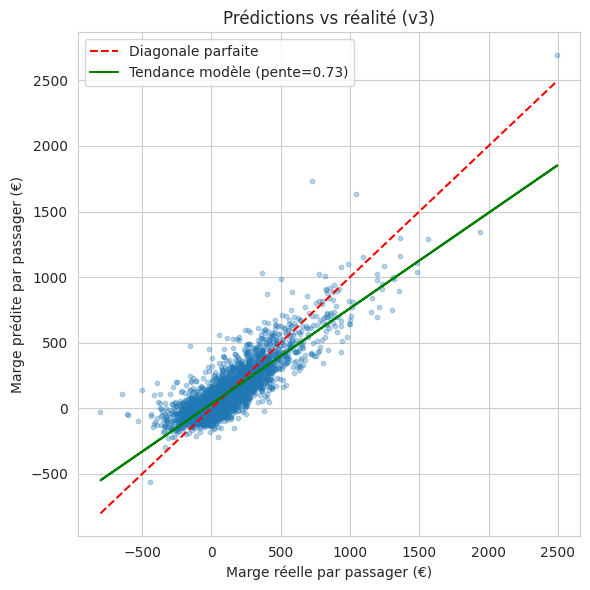

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Diagonale parfaite')
z = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, np.poly1d(z)(y_test), 'g-', linewidth=1.5, label=f'Tendance modèle (pente={z[0]:.2f})')
plt.xlabel('Marge réelle par passager (€)')
plt.ylabel('Marge prédite par passager (€)')
plt.title('Prédictions vs réalité (v3)')
plt.legend()
plt.tight_layout()
plt.show()

Compare ce graphique à celui de la v2 : les points doivent suivre nettement mieux la diagonale
rouge sur toute la plage, y compris pour les marges élevées à droite.

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("R² par fold :", np.round(cv_scores, 3))
print(f"R² moyen : {cv_scores.mean():.3f} (± {cv_scores.std():.3f})")

R² par fold : [0.727 0.691 0.693 0.713 0.724]
R² moyen : 0.709 (± 0.015)


## 4. Validation croisée

## 5. Feature importance

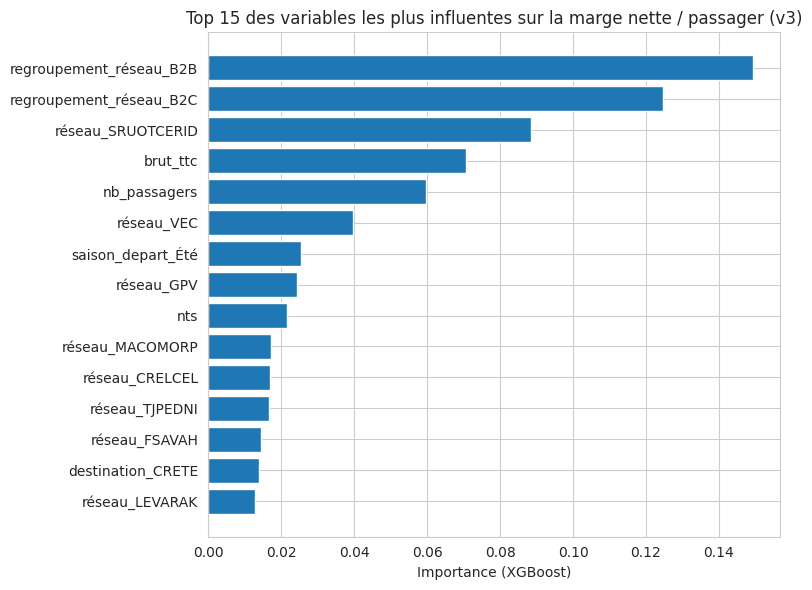

,feature,importance
75,regroupement_réseau_B2B,0.149262
76,regroupement_réseau_B2C,0.124621
43,réseau_SRUOTCERID,0.088559
3,brut_ttc,0.070582
1,nb_passagers,0.059689
69,réseau_VEC,0.039721
80,saison_depart_Été,0.025467
22,réseau_GPV,0.024310
2,nts,0.021590
30,réseau_MACOMORP,0.017234


In [20]:
cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(FEATURES_CAT)
all_feature_names = FEATURES_NUM + list(cat_feature_names)

importances = model.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
top15 = importance_df.head(15)
plt.barh(top15['feature'][::-1], top15['importance'][::-1])
plt.title('Top 15 des variables les plus influentes sur la marge nette / passager (v3)')
plt.xlabel('Importance (XGBoost)')
plt.tight_layout()
plt.show()

importance_df.head(15)

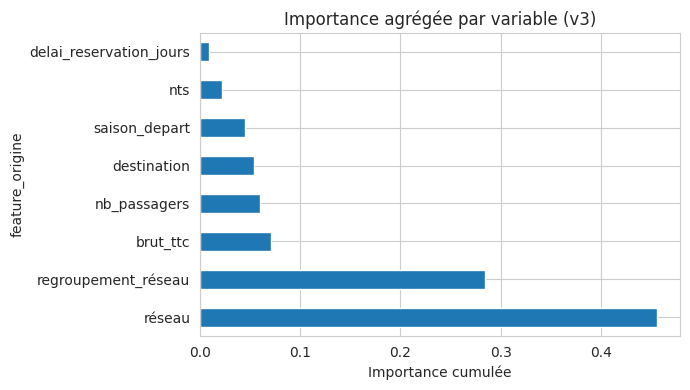

feature_origine
réseau                     0.456323
regroupement_réseau        0.283933
brut_ttc                   0.070582
nb_passagers               0.059689
destination                0.054235
saison_depart              0.044785
nts                        0.021590
delai_reservation_jours    0.008864
Name: importance, dtype: float32


In [21]:
importance_df['feature_origine'] = importance_df['feature'].apply(
    lambda x: next((f for f in FEATURES_CAT if x.startswith(f)), x)
)
importance_agg = importance_df.groupby('feature_origine')['importance'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importance_agg.plot(kind='barh')
plt.title('Importance agrégée par variable (v3)')
plt.xlabel('Importance cumulée')
plt.tight_layout()
plt.show()

print(importance_agg)